# **Lab 7 - Uninformed Search**
## **G00417466 - Eoin Ocathasaigh**

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from copy import deepcopy
# For cleaner notebook output
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

## **Part 1: Building a Semantic Network with NetworkX**
A **semantic network** is a graph consisting of **nodes** (vertices) connected by **links** (edges). Nodes represent objects or states, and edges represent
relationships between them. In AI, semantic networks are used to represent a problem's **search space** — the set of all possible states and the transitions
between them.

A **semantic tree** is a special case of a semantic network with no cycles. Many search spaces, however, contain cycles (e.g., you can walk from room A to room
B and back again). The presence of cycles means our search algorithms must track visited nodes to avoid infinite loops. (no generative AI help allowed).

### 1.2 The Maze Graph
The figure below illustrates the maze drawing: (in brief)

The graph below represents this maze. Node **S** is the starting point and node **T** is the exit (goal). The graph is **undirected** (edges go both ways) and contains **cycles** — which makes it a more realistic and interesting search problem than a tree.

The graph has the following structure:
- S connects to 1, 6, 8
- 1 connects to 2, 3
- 2 connects to 10, 11 (both dead ends)
- 3 connects to 12 (dead end), 4
- 4 connects to 13 (dead end), 5
- 5 connects to 6, 9
- 6 connects to 7
- 7 connects to 8, 9
- 8 connects to 14 (dead end)
- 9 connects to T (the goal!)

Let's build this graph using NetworkX and visualise it.

In [9]:
# Build the maze graph
maze = nx.Graph()

# Add all edges (undirected — each edge goes both ways)
maze_edges = [
    ('S', '1'), ('S', '6'), ('S', '8'),
    ('1', '2'), ('1', '3'),
    # TODO: add the edges for nodes 2 to 8
    ('2', '10'), ('2', '11'),
    ('3', '12'), ('3', '4'),
    ('4', '13'), ('4', '5'),
    ('5', '6'), ('5', '9'),
    ('6', '7'),
    ('7', '8'), ('7', '9'),
    ('8', '14'),
    ('9', 'T')
]
maze.add_edges_from(maze_edges)

print(f"Nodes ({maze.number_of_nodes()}): {sorted(maze.nodes())}")
print(f"Edges ({maze.number_of_edges()}): {list(maze.edges())}")
print(f"\nDead-end nodes (degree 1): {[n for n in maze.nodes() if maze.degree(n) == 1]}")
print(f"Cycles present: {len(nx.cycle_basis(maze)) > 0}")

Nodes (16): ['1', '10', '11', '12', '13', '14', '2', '3', '4', '5', '6', '7', '8', '9', 'S', 'T']
Edges (18): [('S', '1'), ('S', '6'), ('S', '8'), ('1', '2'), ('1', '3'), ('6', '5'), ('6', '7'), ('8', '7'), ('8', '14'), ('2', '10'), ('2', '11'), ('3', '12'), ('3', '4'), ('4', '13'), ('4', '5'), ('5', '9'), ('9', '7'), ('9', 'T')]

Dead-end nodes (degree 1): ['10', '11', '12', '13', '14', 'T']
Cycles present: True


## 1.3 Visualising the Graph
A good visualisation helps us understand the structure of the search space. We'll assign fixed positions to each node so that the layout is consistent across all our plots. We'll also colour-code nodes by their role: start (green), goal (red), dead ends (orange), and regular nodes (blue).

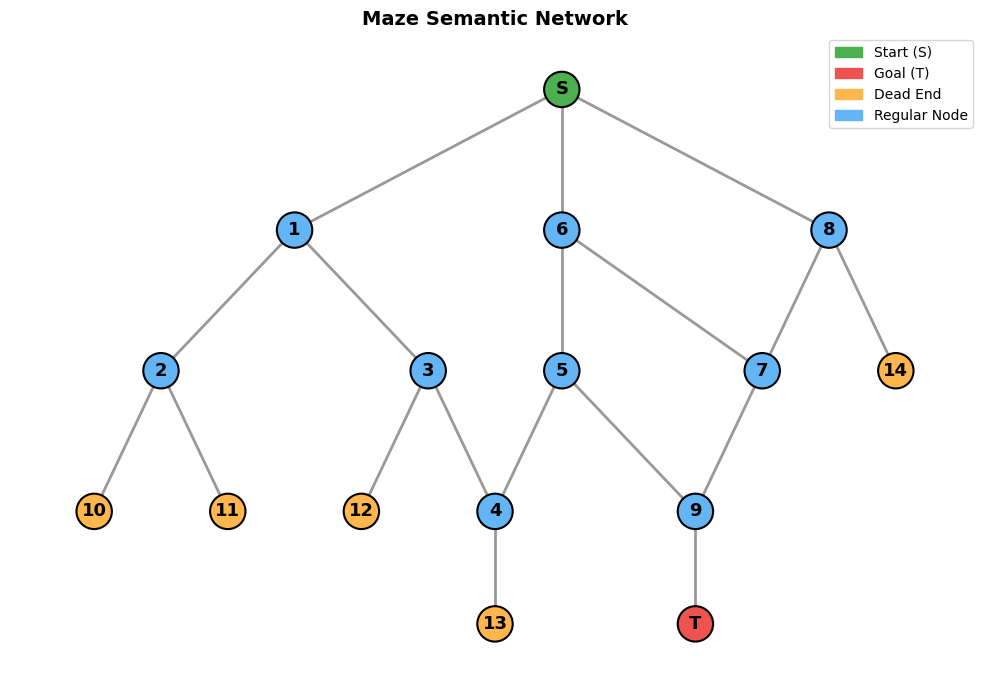

In [10]:
# Fixed positions for consistent layout
maze_pos = {
    'S': (0, 3),
    '1': (-2, 2), '6': (0, 2), '8': (2, 2),
    '2': (-3, 1), '3': (-1, 1), '5': (0, 1), '7': (1.5, 1),
    '10': (-3.5, 0), '11': (-2.5, 0), '12': (-1.5, 0), '4': (-0.5, 0),
    '14': (2.5, 1),
    '13': (-0.5, -0.8),
    '9': (1, 0),
    'T': (1, -0.8)
}

def get_node_colors(graph, start='S', goal='T'):
    """Return a list of colours for each node based on its role."""
    colors = []
    for n in graph.nodes():
        if n == start:
            colors.append('#4CAF50') # Green — start
        elif n == goal:
            colors.append('#EF5350') # Red — goal
        elif graph.degree(n) == 1:
            colors.append('#FFB74D') # Orange — dead end
        else:
            colors.append('#64B5F6') # Blue — regular
    return colors

def draw_maze(graph, pos, title='Maze Semantic Network',
        highlight_edges=None, highlight_nodes=None):
    """Draw the maze graph with optional highlighted path."""
    fig, ax = plt.subplots(figsize=(10, 7))

    node_colors = get_node_colors(graph)

    # Draw base graph
    nx.draw(graph, pos, ax=ax, with_labels=True,
    node_color=node_colors, node_size=650,
    font_size=13, font_weight='bold',
    edge_color='#999999', width=2,
    edgecolors='black', linewidths=1.5)

    # Highlight path if provided
    if highlight_edges:
        nx.draw_networkx_edges(graph, pos, edgelist=highlight_edges,
        edge_color='#E91E63', width=4, ax=ax)

    if highlight_nodes:
        nx.draw_networkx_nodes(graph, pos, nodelist=highlight_nodes,
            node_color='#E91E63', node_size=650,
            edgecolors='black', linewidths=1.5, ax=ax)
        nx.draw_networkx_labels(graph, pos,
            labels={n: n for n in highlight_nodes},
            font_size=13, font_weight='bold', ax=ax)

    # Legend
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='Start (S)'),
        mpatches.Patch(color='#EF5350', label='Goal (T)'),
        mpatches.Patch(color='#FFB74D', label='Dead End'),
        mpatches.Patch(color='#64B5F6', label='Regular Node'),
    ]

    if highlight_edges:
        legend_elements.append(mpatches.Patch(color='#E91E63', label='Found Path'))
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Draw the maze
draw_maze(maze, maze_pos)

### 1.4 Understanding the Graph Structure
Before running any search algorithms, let's answer a few questions about the graph.

**Key observation:** The average degree of the graph gives us an estimate of the **branching factor** b . The branching factor is crucial because it
determines the time complexity (O(b^d)) and space complexity of search algorithms, where is the depth of the goal node. 

In [11]:
# Basic graph properties
print("Graph Properties")
print("=" * 40)
# TODO: code to print the number of nodes
print(f"Number of nodes: {maze.number_of_nodes()}")
# TODO: code to print the number of edges
print(f"Number of edges: {maze.number_of_edges()}")

print(f"Average degree: {sum(dict(maze.degree()).values()) / maze.number_of_nodes():.2f}")
print(f"Number of cycles: {len(nx.cycle_basis(maze))}")

print(f"\nAdjacency list:")
for node in sorted(maze.nodes()):
    neighbors = sorted(maze.neighbors(node))
    print(f" {node:>2} -> {neighbors}")

Graph Properties
Number of nodes: 16
Number of edges: 18
Average degree: 2.25
Number of cycles: 3

Adjacency list:
  1 -> ['2', '3', 'S']
 10 -> ['2']
 11 -> ['2']
 12 -> ['3']
 13 -> ['4']
 14 -> ['8']
  2 -> ['1', '10', '11']
  3 -> ['1', '12', '4']
  4 -> ['13', '3', '5']
  5 -> ['4', '6', '9']
  6 -> ['5', '7', 'S']
  7 -> ['6', '8', '9']
  8 -> ['14', '7', 'S']
  9 -> ['5', '7', 'T']
  S -> ['1', '6', '8']
  T -> ['9']


## **Part 2: Breadth-First Search (BFS)**
### 2.1 How BFS Works
BFS explores a graph **level by level**. Starting from the initial node, it first visits all nodes at depth 1, then all nodes at depth 2, and so on. It uses a FIFO queue
(First-In, First-Out) to maintain the frontier of nodes to explore.
**Algorithm:**
1. Place the starting node in a queue.
2. While the queue is not empty:
- Remove the node from the front of the queue.
- If it is the goal, return success (and the path).
- Otherwise, mark it as visited and add its unvisited neighbours to the back of the queue.

**Properties:**
- **Complete:** Yes — BFS will always find a goal if one exists (on finite graphs).
- **Optimal:** Yes — BFS finds the shallowest goal node, which on an unweighted graph is the shortest path.
- **Time complexity:** where is the branching factor and is the depth of the shallowest goal.
- **Space complexity:** — BFS must store all nodes at the current level plus the next level.

### 2.2 BFS Implementation
We'll implement BFS from scratch using Python's collections.deque as our FIFO queue. The function returns both the **traversal order** (the order in which
nodes were visited) and the **path** from start to goal.


In [12]:
def bfs(graph, start, goal):
    """
    Breadth-First Search on a NetworkX graph.

    Parameters:
    graph: A NetworkX graph
    start: The starting node
    goal: The goal node

    Returns:
    traversal_order: List of nodes in the order they were visited
    path: List of nodes forming the path from start to goal
    (None if no path exists)
    queue_states: List of queue snapshots at each step (for tracing)
    """
    visited = set()
    # Each queue entry is (node, path_to_node)
    queue = deque([(start, [start])])
    traversal_order = []
    queue_states = []

    while queue:
        # Record the current state of the queue (for tracing)
        queue_states.append([node for node, _ in queue])

        # Dequeue from the FRONT (FIFO)
        # TODO: use the proper function to dequeue and get 'node' and 'path' from 'queue'
        node, path = queue.popleft()

        if node in visited:
            continue

        # TODO: add 'node' to 'visited'
        visited.add(node)

        traversal_order.append(node)

        # Goal test
        if node == goal:
            return traversal_order, path, queue_states

        # Enqueue unvisited neighbours at the BACK
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))

    return traversal_order, None, queue_states

### 2.3 Running BFS on the Maze
Let's run BFS on our maze and examine the traversal order and the path found.

In [13]:
bfs_order, bfs_path, bfs_queues = bfs(maze, 'S', 'T')

print("BFS Traversal Order:", bfs_order)
print(f"\nPath found: {' -> '.join(bfs_path)}")
print(f"Path length: {len(bfs_path) - 1} edges")

BFS Traversal Order: ['S', '1', '6', '8', '2', '3', '5', '7', '14', '10', '11', '12', '4', '9', '13', 'T']

Path found: S -> 6 -> 5 -> 9 -> T
Path length: 4 edges
